In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

In [ ]:
np.random.seed(19) #ensure reproducibility
npoints = 50
x_data = np.linspace(1, 10, npoints)

In [ ]:
#create a clean exponential dataset, then add Gaussian scatter to simulate real data
sigma = 0.2
y_clean = 5.0 * np.exp(-0.5 * x_data) 
scatter = np.random.normal(scale=sigma, size=npoints) 
y_data = y_clean + scatter
y_err = np.full(npoints, sigma)

In [11]:
#define the two models
def model_exp(x, a, b):
    """First model: y = a * exp(-b * x)"""
    return a * np.exp(-b * x)

def model_power(x, a, b):
    """Second model: y = a / (x**b)"""
    return a / (x**b)

In [12]:
# fit data using curve_fit shich should  returns the best-fit parameters and the covariance matrix
params_exp, cov_exp = curve_fit(model_exp, x_data, y_data, sigma=y_err)
params_pow, cov_pow = curve_fit(model_power, x_data, y_data, sigma=y_err)

a_exp, b_exp = params_exp
a_pow, b_pow = params_pow

# print  best-fit results 
print(f"Exponential Model Fit: a = {a_exp:4.3f}, b = {b_exp:4.3f}")
print(f"Power-law Model Fit:   a = {a_pow:4.3f}, b = {b_pow:4.3f}")

Exponential Model Fit: a = 4.695, b = 0.474
Power-law Model Fit:   a = 3.493, b = 1.195


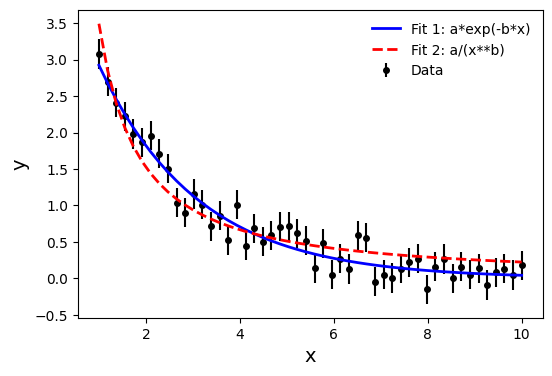

In [13]:

#plot the data 
f, ax = plt.subplots(1, 1, figsize=(6, 4)) 

ax.errorbar(x_data, y_data, yerr=y_err, fmt='o', color='black', 
            markersize=4, label='Data', zorder=0)

# Exponential Model Fit
ax.plot(x_data, model_exp(x_data, a_exp, b_exp), 
        color='blue', linewidth=2, label='Fit 1: a*exp(-b*x)', zorder=1)

# Power-Law Model Fit
ax.plot(x_data, model_power(x_data, a_pow, b_pow), 
        color='red', linestyle='--', linewidth=2, label='Fit 2: a/(x**b)', zorder=2)

ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.legend(loc='upper right', frameon=False) 

#Save  a PDF
plt.savefig('best_fit_models.pdf', bbox_inches='tight', dpi=400)
plt.show()